# Quoting Engine

A market maker quotes a bid/ask spread centered on the fair value point from Heston.

Order arrivals are modeled with a Poisson process. The Avellaneda-Stoikov framework 
derives optimal bid/ask quotes by computing a reservation price adjusted for inventory 
risk, then placing a spread symmetrically around it.

The notebook builds up from a single-expiry baseline to a full multi-expiry simulation 
with portfolio-level delta netting across 6 TLT option expiries.

**Outputs:** bid/ask quotes, inventory paths per expiry, book-level P&L, hedge position, 
and three-bucket P&L attribution (cash / MTM / hedge).

In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from scipy.stats import norm

In [2]:
# grab Vasicek params from calibration
with open("../data/vasicek_params.json") as f:
    params = json.load(f)

r0       = params['r0']         # current spot rate
kappa_r  = params['kappa']      # rate mean reversion speed
theta_r  = params['theta']      # long-run mean rate
sigma_r  = params['sigma_r']    # rate volatility
rho_rS   = -0.7                 # correlation between rate and TLT shocks (negative for TLT)

# market snapshot - April 24th, 2026 close
S0 = 86.71  # TLT spot price

# PLACEHOLDERS — replace with Heston output 
# fair_value and sigma will be per-expiry once Heston surface is calibrated
# PLACEHOLDERS — replace with Heston output 
# fair_value: rough BS ATM call prices (K = S0, sigma = 0.15)
# will be replaced with per-strike Heston surface from Person A
fair_value = {
    'May15': 1.34,
    'Jun18': 2.26,
    'Jul17': 2.86,
    'Aug21': 3.49,
    'Sep18': 3.95,
    'Oct16': 4.37
}
sigma = {
    'May15': 0.15, 'Jun18': 0.15, 'Jul17': 0.15,
    'Aug21': 0.15, 'Sep18': 0.15, 'Oct16': 0.15
}

# option expiries — days to expiry from April 24, 2026, expressed in years
expiries = {
    'May15':  21/365,
    'Jun18':  55/365,
    'Jul17':  84/365,
    'Aug21': 119/365,
    'Sep18': 147/365,
    'Oct16': 175/365
}

# market making parameters (used by both single and multi-expiry sims)
gamma                   = 0.1   # risk aversion
kappa_MM                = 50   # order arrival rate (per year per side per expiry)
max_inventory           = 3     # hard inventory limit per expiry per side
max_portfolio_inventory = 10    # cap on |sum of inventory across all expiries|

print(f"r0: {r0}")
print(f"S0: {S0}")
print(f"fair_value: {fair_value}")
print(f"sigma: {sigma}")
print(f"gamma: {gamma}, kappa_MM: {kappa_MM}, max_inv: {max_inventory}, max_port_inv: {max_portfolio_inventory}")

r0: 0.0369
S0: 86.71
fair_value: {'May15': 1.34, 'Jun18': 2.26, 'Jul17': 2.86, 'Aug21': 3.49, 'Sep18': 3.95, 'Oct16': 4.37}
sigma: {'May15': 0.15, 'Jun18': 0.15, 'Jul17': 0.15, 'Aug21': 0.15, 'Sep18': 0.15, 'Oct16': 0.15}
gamma: 0.1, kappa_MM: 50, max_inv: 3, max_port_inv: 10


### Avellaneda-Stoikov

Academic standard for options market making. The core idea: you don't quote symmetrically around fair value - you skew your quotes based on your inventory to manage risk.

Three formulas:
$$r_{price} = \text{fair\_value} - \text{inventory} \cdot \gamma \cdot \sigma^2 \cdot (T - t)$$

$$\text{spread} = \gamma \cdot \sigma^2 \cdot (T-t) + \frac{2}{\gamma} \ln\left(1 + \frac{\gamma}{\kappa_{MM}}\right)$$

$$\text{bid} = r_{price} - \frac{\text{spread}}{2}, \quad \text{ask} = r_{price} + \frac{\text{spread}}{2}$$

Parameters:
* $\gamma$      : Our risk aversion. Higher = wider spreads, more aggressive inventory skew
* $\kappa_{MM}$ : Rate at which orders arrive. Higher = tighter spreads (more flow = less need to widen)
* $T$           : Expiration of the option
* $t$           : current time (start at 0)
* inventory     : Start at zero

In [3]:
# parameters — quick sanity check on May15 expiry
T = expiries['May15']
t = 0.0
inventory = 0

# pull values for this single test
fv  = fair_value['May15']
vol = sigma['May15']

# calculations
r_price = fv - inventory * gamma * vol**2 * (T-t)
spread  = gamma * vol**2 * (T-t) + (2/gamma) * np.log(1 + (gamma/kappa_MM))
bid = r_price - (spread/2)
ask = r_price + (spread/2)

print(r_price, spread, bid, ask)

1.34 0.040089505308255675 1.3199552473458722 1.360044752654128


### Discrete Delta Hedging
Delta measures the sensitivity of our option's value to a `$1` move in TLT. A delta of 0.5 means if TLT moves up `$1`, our option gains `$0.50`.

As market makers we don't want to take a directional bet on TLT — we just 
want to capture spread. So we hedge delta by trading TLT shares to offset 
our option exposure, keeping us approximately direction-neutral.

We hedge discretely — once per day — rather than continuously. This is 
realistic since continuous hedging is impossible in practice and incurs 
infinite transaction costs. The gap between our discrete hedge and the 
theoretically perfect continuous hedge is called **delta hedge slippage**, 
which we will track as part of our P&L attribution.

Delta is calculated using the Black-Scholes formula — not for pricing, 
but as a translation tool to convert our Heston fair value into a 
hedgeable Greeks exposure.

In [4]:
def bs_delta(S, K, r, sigma, T):
    d1 = (np.log(S/K) + (r + sigma **2 / 2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

# quick sanity check on May15 expiry
print(bs_delta(S0, S0, r0, sigma['May15'], expiries['May15']))


0.5306866423728474


### TLT Price Path Simulation
We simulate TLT prices over a 175-day window (the longest expiry) using Geometric Brownian Motion (GBM), 
with our calibrated Vasicek spot rate r0 as the drift. This allows our delta hedge 
to respond to actual price moves rather than a static spot price. The same path 
is shared across all expiries in the multi-expiry simulation below.

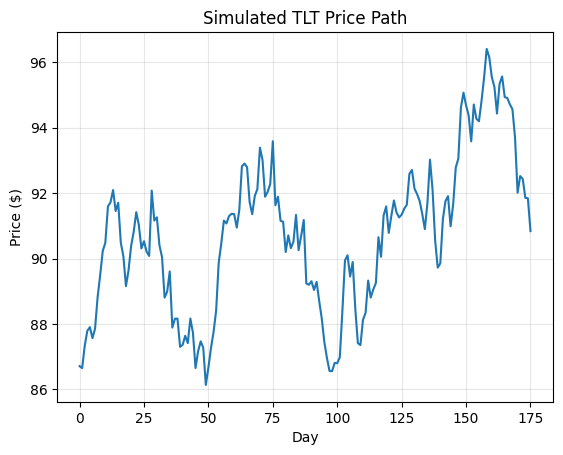

In [5]:
def simulate_tlt_path(S0, r0, sigma, T_days, seed = None):
    if seed is not None:
        np.random.seed(seed)
    dt = 1/365
    prices = [S0]
    for i in range(T_days):
        dW = np.random.normal(0, np.sqrt(dt))
        S_new = prices[-1] * np.exp((r0 - 0.5 * sigma**2) * dt + sigma * dW)
        prices.append(S_new)
    return np.array(prices)

# use longest-dated IV as proxy for TLT path vol
tlt_path = simulate_tlt_path(S0, r0, sigma['Oct16'], T_days=175)

# plot TLT path
plt.plot(tlt_path)
plt.title('Simulated TLT Price Path')
plt.xlabel('Day')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3)
plt.show()

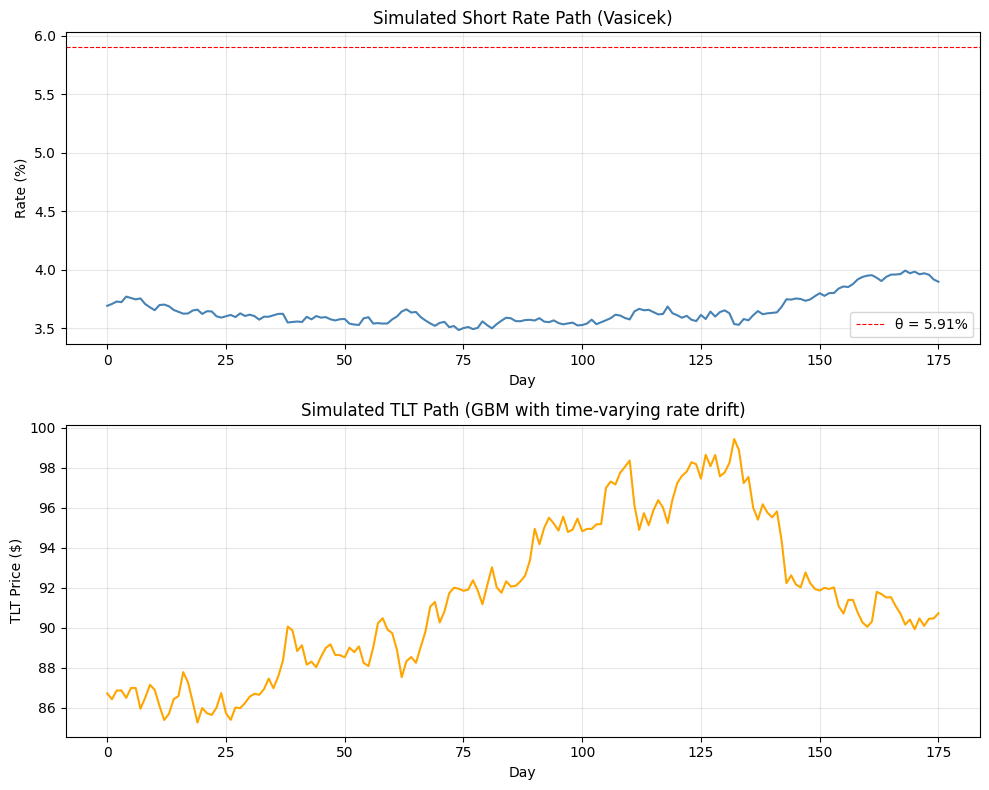

In [6]:
def simulate_coupled_paths(S0, r0, kappa_r, theta_r, sigma_r, sigma_S, 
                           T_days, rho=-0.7, seed=None):
    """
    Joint simulation of short rate (Vasicek) and TLT price (GBM with time-varying drift).
    
    The rate-TLT correlation captures the empirical 'rates ↑ → TLT ↓' dynamic.
    
    Returns:
        rate_path: array of length T_days+1, the simulated short rate
        tlt_path:  array of length T_days+1, the simulated TLT price
    """
    if seed is not None:
        np.random.seed(seed)
    
    dt = 1/365
    rates  = [r0]
    prices = [S0]
    
    for _ in range(T_days):
        # correlated Brownian shocks
        z1 = np.random.normal(0, 1)
        z2 = np.random.normal(0, 1)
        dW_r = z1 * np.sqrt(dt)
        dW_S = (rho * z1 + np.sqrt(1 - rho**2) * z2) * np.sqrt(dt)
        
        # Vasicek step (Euler-Maruyama discretization)
        r_new = rates[-1] + kappa_r * (theta_r - rates[-1]) * dt + sigma_r * dW_r
        
        # TLT step with time-varying drift = current rate
        S_new = prices[-1] * np.exp((rates[-1] - 0.5 * sigma_S**2) * dt + sigma_S * dW_S)
        
        rates.append(r_new)
        prices.append(S_new)
    
    return np.array(rates), np.array(prices)


# quick sanity check + dual plot
rate_path, tlt_path_test = simulate_coupled_paths(
    S0, r0, kappa_r, theta_r, sigma_r, sigma['Oct16'],
    T_days=175, rho=rho_rS, seed=42
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(rate_path * 100, color='steelblue')
ax1.axhline(theta_r * 100, color='red', linestyle='--', linewidth=0.8, label=f'θ = {theta_r*100:.2f}%')
ax1.set_title('Simulated Short Rate Path (Vasicek)')
ax1.set_xlabel('Day')
ax1.set_ylabel('Rate (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(tlt_path_test, color='orange')
ax2.set_title('Simulated TLT Path (GBM with time-varying rate drift)')
ax2.set_xlabel('Day')
ax2.set_ylabel('TLT Price ($)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Poisson Order Arrival Simulation
At each daily time step, buyers and sellers arrive randomly via independent Poisson processes 
with arrival rate `kappa_MM` per side. Not every arrival results in a fill — fill probability 
decays exponentially with the quote's distance from fair value. This captures adverse selection: 
the further our quote is from fair value, the less likely we get hit by an informed trader.

We track inventory, P&L, and recalculate reservation price and spread at each step to reflect inventory skew.

### Single-Expiry Simulation (May 15 only)

Baseline run on the May 15 expiry only. Used as a sanity check before scaling to the full multi-expiry portfolio below.

Final inventory:     0
Bids filled:         1
Asks filled:         1
Cash P&L:            0.0400
Mark-to-market P&L: 0.0000
Hedge P&L:           1.6466
Total P&L:           1.6866
Current TLT shares:  0.0000


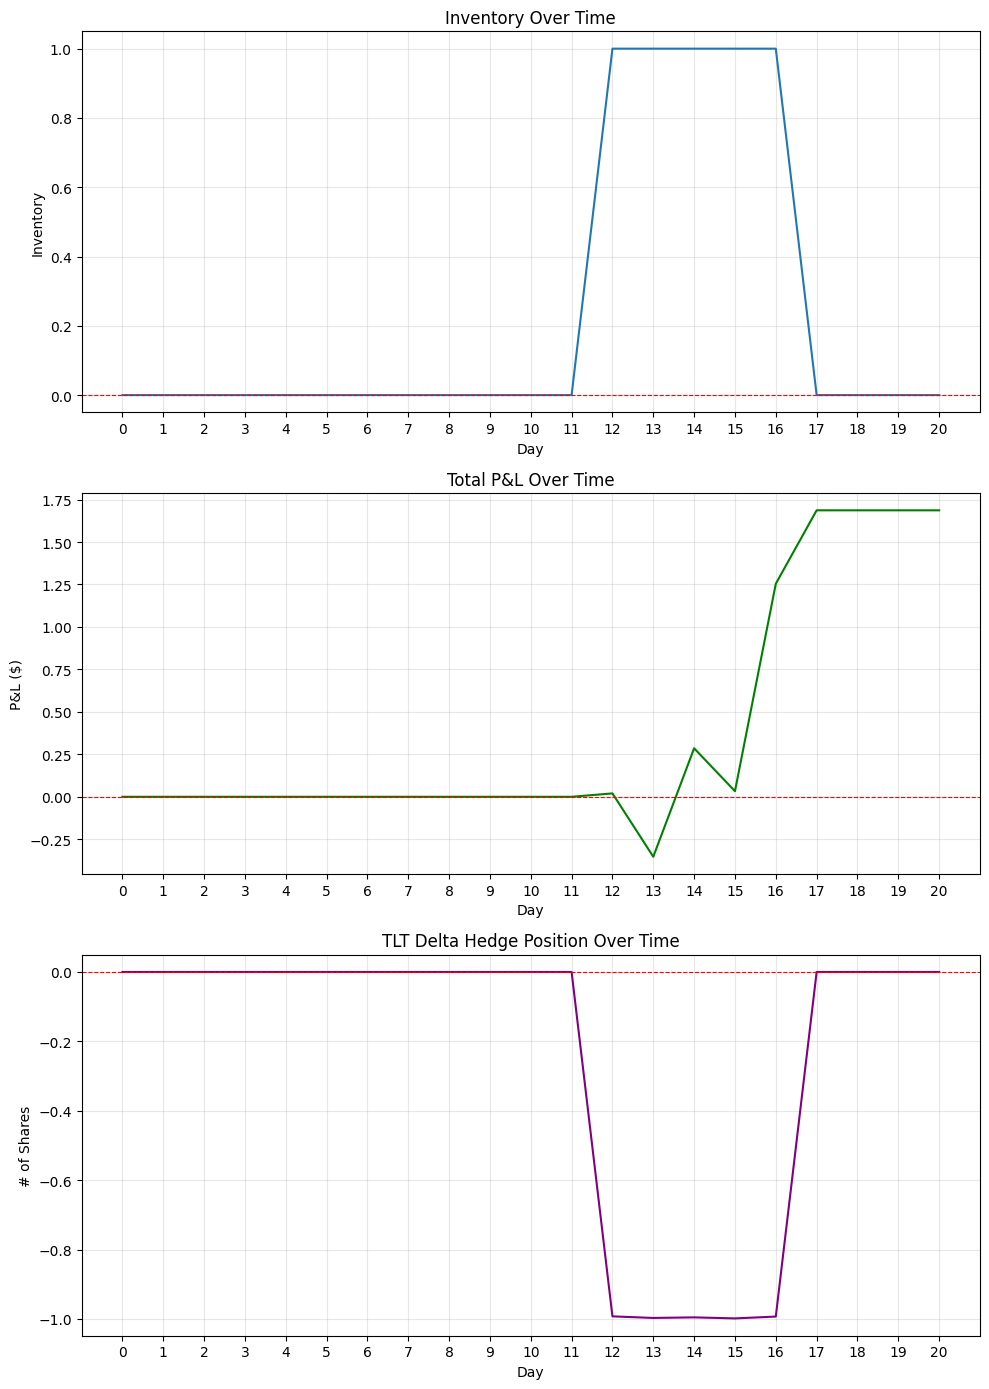

In [7]:
# single expiry baseline (May15 only)
T = expiries['May15']

# initialize tracking variables
inventory = 0          # current net position (+ = long, - = short)
bids_filled = 0        # number of times a seller hit our bid (we bought)
asks_filled = 0        # number of times a buyer hit our ask (we sold)
pnl = 0                # cumulative cash P&L from spread capture
inventory_track = []   # daily inventory snapshots for plotting
pnl_track = []         # daily total P&L snapshots for plotting
shares_track = []      # daily TLT share position snapshots for plotting
current_shares = 0     # how many TLT shares we currently hold as our delta hedge
hedge_pnl = 0          # cumulative P&L from TLT share position moving

# pull May15 values once for readability
fv  = fair_value['May15']
vol = sigma['May15']

# main simulation loop — one day at a time over 21 day option window
for day in range(21):
    t = day / 365  # current time in years

    # --- QUOTING ---
    # A-S reservation price skews our mid based on inventory
    # long inventory → shade quotes lower to attract sellers
    r_price = fv - inventory * gamma * vol**2 * (T - t)
    spread = gamma * vol**2 * (T - t) + (2/gamma) * np.log(1 + (gamma/kappa_MM))
    bid = r_price - (spread/2)
    ask = r_price + (spread/2)

    # --- ORDER ARRIVALS ---
    # buyers and sellers arrive randomly each day via Poisson process
    # kappa_MM is annual so we scale to daily
    buyers = np.random.poisson(kappa_MM / 365)
    sellers = np.random.poisson(kappa_MM / 365)

    # --- FILL PROBABILITY ---
    # arriving orders don't always fill — probability decays with distance from fair value
    # this captures adverse selection: informed traders only fill us when our price is off
    prob_bid = np.exp(-kappa_MM * (fv - bid))
    prob_ask = np.exp(-kappa_MM * (ask - fv))

    # --- FILLS ---
    # ask side: buyer wants to buy from us — only allow if not at short limit
    if inventory > -max_inventory:
        if buyers > 0 and np.random.rand() < prob_ask:
            inventory -= 1    # we sold a contract
            asks_filled += 1
            pnl += ask        # cash inflow at ask price

    # bid side: seller wants to sell to us — only allow if not at long limit
    if inventory < max_inventory:
        if sellers > 0 and np.random.rand() < prob_bid:
            inventory += 1    # we bought a contract
            bids_filled += 1
            pnl -= bid        # cash outflow at bid price

    # --- DELTA HEDGE ---
    # calculate BS delta using today's simulated TLT price
    # target_shares is how many TLT shares we need to hold to be delta neutral
    # negative sign because we're offsetting our option exposure
    delta = bs_delta(tlt_path[day], S0, r0, vol, T - t)
    target_shares = -inventory * delta

    # mark-to-market our existing share position before rebalancing
    # captures gain/loss from TLT moving since yesterday
    if day > 0:
        hedge_pnl += current_shares * (tlt_path[day] - tlt_path[day - 1])

    # rebalance hedge to new target
    current_shares = target_shares

    # --- END OF DAY SNAPSHOT ---
    inventory_track.append(inventory)
    pnl_track.append(pnl + inventory * fv + hedge_pnl)
    shares_track.append(current_shares)

# --- FINAL P&L ATTRIBUTION ---
mtm_pnl = inventory * fv       # mark-to-market value of remaining option inventory
total_pnl = pnl + mtm_pnl + hedge_pnl # spread capture + inventory MTM + hedge gains

# store daily results in dataframe
tracking_df = pd.DataFrame({'Inventory': inventory_track, 'Total P&L': pnl_track, 'TLT Shares': shares_track})

print(f"Final inventory:     {inventory}")
print(f"Bids filled:         {bids_filled}")
print(f"Asks filled:         {asks_filled}")
print(f"Cash P&L:            {pnl:.4f}")
print(f"Mark-to-market P&L: {mtm_pnl:.4f}")
print(f"Hedge P&L:           {hedge_pnl:.4f}")
print(f"Total P&L:           {total_pnl:.4f}")
print(f"Current TLT shares:  {current_shares:.4f}")

# --- PLOTS ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 14))

ax1.plot(range(21), inventory_track)
ax1.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax1.set_title('Inventory Over Time')
ax1.set_xlabel('Day')
ax1.set_ylabel('Inventory')
ax1.set_xticks(range(21))
ax1.grid(True, alpha=0.3)

ax2.plot(range(21), pnl_track, color='green')
ax2.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax2.set_title('Total P&L Over Time')
ax2.set_xlabel('Day')
ax2.set_ylabel('P&L ($)')
ax2.set_xticks(range(21))
ax2.grid(True, alpha=0.3)

ax3.plot(range(21), shares_track, color='purple')
ax3.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax3.set_title('TLT Delta Hedge Position Over Time')
ax3.set_xlabel('Day')
ax3.set_ylabel('# of Shares')
ax3.set_xticks(range(21))
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Multi-Expiry Simulation (Portfolio Delta Netting)

We now run the market maker across all 6 TLT expiries simultaneously.

**Key design decisions:**
- **One shared TLT price path** — 175 days (longest expiry, Oct 16)
- **Per-expiry tracking** — inventory, P&L, hedge P&L, and fills stored in dicts keyed by expiry name
- **Per-expiry sigma and fair_value** — pulled from the Heston surface (currently flat placeholders)
- **Portfolio-level delta netting** — each day, sum delta × inventory across all active expiries, execute one shared TLT hedge trade
- **Expiry dropout** — once `t >= T` for an expiry, we stop quoting it and lock in its MTM at final fair value
- **One `current_shares` variable** — the single shared TLT hedge position for the whole book

**Risk limits — two layered caps:**
- `max_inventory = 3` — per-expiry concentration cap (per side)
- `max_portfolio_inventory = 10` — absolute cap on |sum of inventory across all expiries|

Per-expiry caps prevent pathological concentration in any single date (pin risk, expiry-specific gamma blowups). The portfolio cap controls total book exposure, which is what a real MM business actually cares about — capital, margin, and net Greek exposure are all portfolio-level concerns.

This two-layer structure mirrors how production MM firms manage risk: portfolio limits as primary control, per-instrument caps as concentration guardrails.

In [8]:
# MULTI-EXPIRY SETUP
def run_simulation(seed=None, track_daily=False):
    """
    Run one full multi-expiry market making simulation.

    Args:
        seed: random seed for reproducibility (None = fresh randomness)
        track_daily: if True, return daily tracking lists for plotting

    Returns:
        dict with summary results, plus daily tracks if track_daily=True
    """
    # per-expiry tracking dicts
    inventory = {name: 0 for name in expiries}
    pnl = {name: 0.0 for name in expiries}
    hedge_pnl = {name: 0.0 for name in expiries}
    bids_filled = {name: 0 for name in expiries}
    asks_filled = {name: 0 for name in expiries}
    mtm_locked = {name: None for name in expiries}
    
    # shared portfolio hedge
    current_shares = 0
    
    # daily tracking for plots
    inventory_track = {name: [] for name in expiries}   # per-expiry inventory each day
    total_pnl_track = []                                 # book-level total P&L each day
    shares_track    = []                                 # portfolio hedge position each day
    
    # simulate TLT path for full 175-day window (longest expiry)
    rate_path, tlt_path = simulate_coupled_paths(
        S0, r0, kappa_r, theta_r, sigma_r, sigma['Oct16'],
        T_days=175, rho=rho_rS, seed=seed
    )
    
    # ------- MAIN LOOP --------- 
    for day in range(175):
        t = day / 365   # current time in years
        portfolio_delta = 0   # accumulates net delta across all active expiries
    
        for name, T_exp in expiries.items():
            # skip expired expiries
            if t  >= T_exp:
                # lock in MTM on the day it expires (only once)
                if mtm_locked[name] is None:
                    mtm_locked[name] = inventory[name] * fair_value[name]
                continue
    
            time_to_exp = T_exp - t
            inv = inventory[name]
            fv = fair_value[name]
            vol = sigma[name]
    
            # --- QUOTING ---
            r_price = fv - inv * gamma * vol**2 * time_to_exp
            spread = gamma * vol**2 * time_to_exp + (2/gamma) * np.log(1 + (gamma/kappa_MM))
            bid = r_price - (spread/2)
            ask = r_price + (spread/2)
    
            # --- ORDER ARRIVALS ---
            buyers = np.random.poisson(kappa_MM / 365)
            sellers = np.random.poisson(kappa_MM / 365)
    
            # --- FILL PROBABILITY ---
            prob_bid = np.exp(-kappa_MM * (fv - bid))
            prob_ask = np.exp(-kappa_MM * (ask - fv))
    
            # --- FILLS ---
            # compute current portfolio inventory (sum across all expiries)
            total_inv = sum(inventory.values())
    
            # ask side: buyer wants to buy from us
            # block if at per-expiry short limit OR if filling would push portfolio further short
            if inv > -max_inventory and total_inv > -max_portfolio_inventory:
                if buyers > 0 and np.random.rand() < prob_ask:
                    inventory[name] -= 1
                    asks_filled[name] += 1
                    pnl[name] += ask
    
            # bid side: seller wants to sell to us
            # block if at per-expiry long limit OR if filling would push portfolio further long
            if inv < max_inventory and total_inv < max_portfolio_inventory:
                if sellers > 0 and np.random.rand() < prob_bid:
                    inventory[name] += 1
                    bids_filled[name] += 1
                    pnl[name] -= bid
    
            # --- ACCUMULATE PORTFOLIO DELTA ---
            delta = bs_delta(tlt_path[day], S0, rate_path[day], vol, time_to_exp)
            portfolio_delta += -inventory[name] * delta
            
        # --- PORTFOLIO HEDGE (one trade for the whole book) ---
        if day > 0:
            # mark existing share position before rebalancing
            # split equally across active expiries for attribution
            active = [n for n, T_exp in expiries.items() if t < T_exp]
            price_move = tlt_path[day] - tlt_path[day - 1]
            hedge_gain = current_shares * price_move
            if active:
                per_expiry_hedge = hedge_gain / len(active)
                for name in active:
                    hedge_pnl[name] += per_expiry_hedge
    
        current_shares = portfolio_delta   # rebalance to net portfolio delta
    
        # daily snapshots (only if requested)
        if track_daily:
            for name in expiries:
                inventory_track[name].append(inventory[name])
            book_total = 0
            for name in expiries:
                cash_n  = pnl[name]
                mtm_n   = mtm_locked[name] if mtm_locked[name] is not None else inventory[name] * fair_value[name]
                hedge_n = hedge_pnl[name]
                book_total += cash_n + mtm_n + hedge_n
            total_pnl_track.append(book_total)
            shares_track.append(current_shares)
    
    # aggregate this run
    cash_total  = sum(pnl.values())
    mtm_total   = sum(mtm_locked[name] if mtm_locked[name] is not None
                      else inventory[name] * fair_value[name]
                      for name in expiries)
    hedge_total = sum(hedge_pnl.values())
    
    result = {
        'cash':        cash_total,
        'mtm':         mtm_total,
        'hedge':       hedge_total,
        'total':       cash_total + mtm_total + hedge_total,
        'inventory':   inventory,
        'pnl':         pnl,
        'hedge_pnl':   hedge_pnl,
        'mtm_locked':  mtm_locked,
        'bids_filled': bids_filled,
        'asks_filled': asks_filled,
    }
    
    if track_daily:
        result['inventory_track'] = inventory_track
        result['total_pnl_track'] = total_pnl_track
        result['shares_track']    = shares_track
        result['tlt_path']        = tlt_path
        result['rate_path']       = rate_path
    
    return result
    

# --- BASELINE RUN: seed=42, with daily tracking for plots ---
result = run_simulation(seed=42, track_daily=True)

# extract for downstream cells (plots cell uses these names)
inventory      = result['inventory']
pnl            = result['pnl']
hedge_pnl      = result['hedge_pnl']
mtm_locked     = result['mtm_locked']
bids_filled    = result['bids_filled']
asks_filled    = result['asks_filled']
inventory_track = result['inventory_track']
total_pnl_track = result['total_pnl_track']
shares_track    = result['shares_track']
tlt_path_multi  = result['tlt_path']

# --- FINAL P&L ATTRIBUTION ---
print('=' * 75)
print(f"{'Expiry':<8} {'Inv':>5} {'Bids':>5} {'Asks':>5} {'Cash':>10} {'MTM':>10} {'Hedge':>10} {'Total':>10}")
print("=" * 75)

for name in expiries:
    inv   = inventory[name]
    cash  = pnl[name]
    mtm   = mtm_locked[name] if mtm_locked[name] is not None else inv * fair_value[name]
    hedge = hedge_pnl[name]
    total = cash + mtm + hedge
    print(f"{name:<8} {inv:>5} {bids_filled[name]:>5} {asks_filled[name]:>5} "
          f"{cash:>10.4f} {mtm:>10.4f} {hedge:>10.4f} {total:>10.4f}")

print("=" * 75)
print(f"{'TOTAL':<8} {'':>5} {'':>5} {'':>5} "
      f"{result['cash']:>10.4f} {result['mtm']:>10.4f} {result['hedge']:>10.4f} {result['total']:>10.4f}")

Expiry     Inv  Bids  Asks       Cash        MTM      Hedge      Total
May15       -1     1     2     1.4000    -1.3400    -0.2899    -0.2299
Jun18       -2     0     2     4.5603    -4.5200    -1.0801    -1.0399
Jul17       -1     1     2     2.9201    -2.8600    -3.6657    -3.6056
Aug21        3     7     4   -10.2485    10.4700    -6.4268    -6.2054
Sep18       -3     4     7    12.0710   -11.8500   -19.1803   -18.9593
Oct16       -3     6     9    13.4119   -13.1100   -21.6212   -21.3193
TOTAL                         24.1147   -23.2100   -52.2640   -51.3594


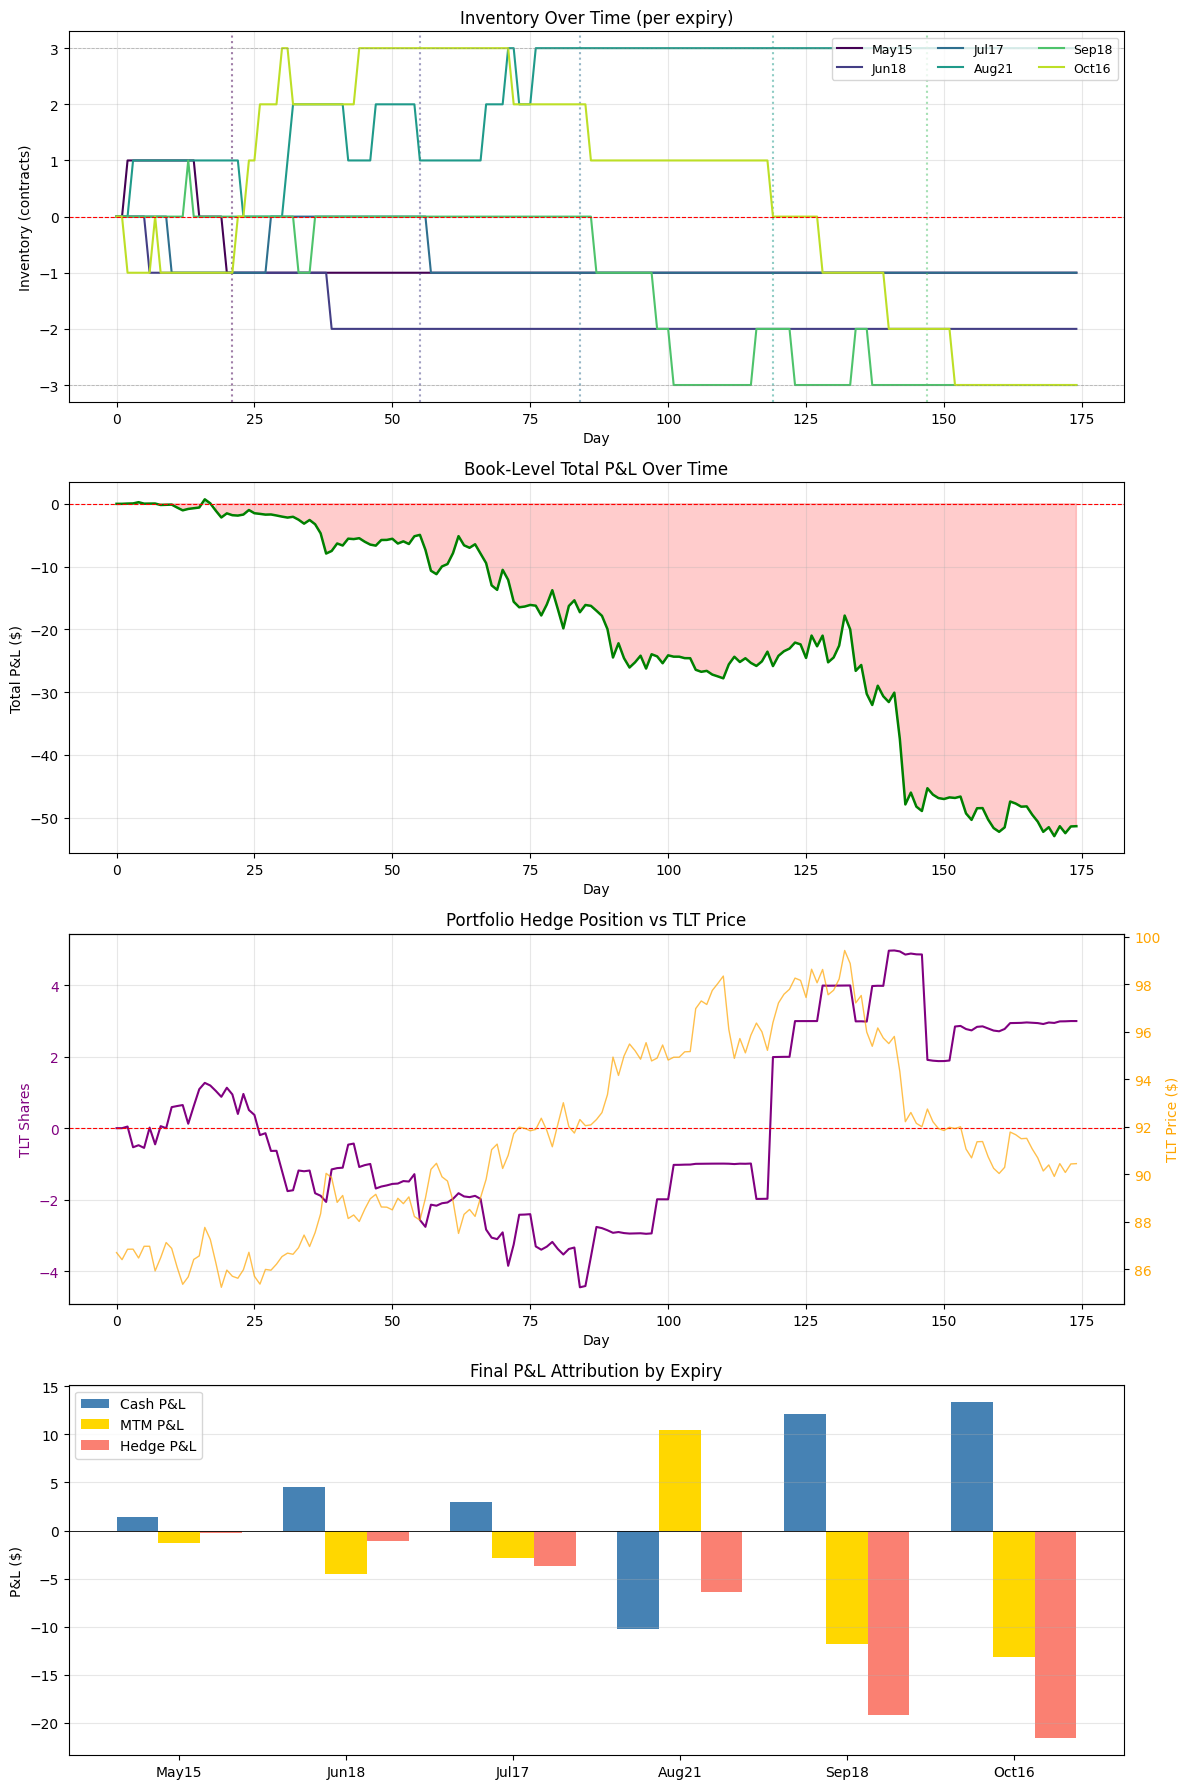

In [9]:
# --- MULTI-EXPIRY PLOTS ---
days = np.arange(175)

fig, axes = plt.subplots(4, 1, figsize=(12, 18))

# 1. INVENTORY PER EXPIRY
ax1 = axes[0]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(expiries)))
for (name, T_exp), color in zip(expiries.items(), colors):
    ax1.plot(days, inventory_track[name], label=name, color=color, linewidth=1.5)
    # mark expiry dropout day with a vertical dashed line
    expiry_day = int(T_exp * 365)
    if expiry_day < 175:
        ax1.axvline(expiry_day, color=color, linestyle=':', alpha=0.5)

ax1.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax1.axhline( max_inventory, color='gray', linestyle='--', linewidth=0.6, alpha=0.5)
ax1.axhline(-max_inventory, color='gray', linestyle='--', linewidth=0.6, alpha=0.5)
ax1.set_title('Inventory Over Time (per expiry)')
ax1.set_xlabel('Day')
ax1.set_ylabel('Inventory (contracts)')
ax1.legend(loc='upper right', ncol=3, fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. CUMULATIVE BOOK-LEVEL P&L
ax2 = axes[1]
ax2.plot(days, total_pnl_track, color='green', linewidth=1.8)
ax2.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax2.fill_between(days, 0, total_pnl_track,
                 where=np.array(total_pnl_track) >= 0, alpha=0.2, color='green')
ax2.fill_between(days, 0, total_pnl_track,
                 where=np.array(total_pnl_track) < 0,  alpha=0.2, color='red')
ax2.set_title('Book-Level Total P&L Over Time')
ax2.set_xlabel('Day')
ax2.set_ylabel('Total P&L ($)')
ax2.grid(True, alpha=0.3)

# 3. PORTFOLIO HEDGE (TLT SHARES) WITH TLT PRICE OVERLAY
ax3 = axes[2]
ax3.plot(days, shares_track, color='purple', linewidth=1.5, label='TLT shares (hedge)')
ax3.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax3.set_title('Portfolio Hedge Position vs TLT Price')
ax3.set_xlabel('Day')
ax3.set_ylabel('TLT Shares', color='purple')
ax3.tick_params(axis='y', labelcolor='purple')
ax3.grid(True, alpha=0.3)

# overlay TLT price on secondary axis
ax3b = ax3.twinx()
ax3b.plot(days, tlt_path_multi[:175], color='orange', linewidth=1, alpha=0.7, label='TLT price')
ax3b.set_ylabel('TLT Price ($)', color='orange')
ax3b.tick_params(axis='y', labelcolor='orange')

# 4. P&L ATTRIBUTION BAR CHART
ax4 = axes[3]
expiry_names = list(expiries.keys())
cash_vals  = [pnl[name] for name in expiry_names]
mtm_vals   = [mtm_locked[name] if mtm_locked[name] is not None else inventory[name] * fair_value[name]
              for name in expiry_names]
hedge_vals = [hedge_pnl[name] for name in expiry_names]

x = np.arange(len(expiry_names))
width = 0.25

ax4.bar(x - width, cash_vals,  width, label='Cash P&L',  color='steelblue')
ax4.bar(x,         mtm_vals,   width, label='MTM P&L',   color='gold')
ax4.bar(x + width, hedge_vals, width, label='Hedge P&L', color='salmon')

ax4.axhline(0, color='black', linewidth=0.6)
ax4.set_xticks(x)
ax4.set_xticklabels(expiry_names)
ax4.set_title('Final P&L Attribution by Expiry')
ax4.set_ylabel('P&L ($)')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Monte Carlo Validation (1,000 paths)

Single-path results are noisy. Hedge P&L on any individual path can swing several
dollars purely from TLT random walk realization. To validate the MM strategy
itself, we run the multi-expiry simulation across 1,000 independent TLT paths
and aggregate the P&L distribution.

**The thesis we're testing:**
- **Cash P&L (spread capture)** should be **positive in expectation** — this is the
  MM business model. Spreads compound over many fills.
- **Hedge P&L** should be **approximately mean-zero** — TLT's random walk is symmetric,
  so over many paths the hedge gains and losses cancel.
- **Total P&L** should be **positive in expectation** with substantial variance.

If hedge P&L turns out to be reliably positive or negative on average, something
is structurally wrong with the hedge. If cash P&L is mean-zero, the spread
isn't compensating for adverse selection.

Completed 100/1000 runs
Completed 200/1000 runs
Completed 300/1000 runs
Completed 400/1000 runs
Completed 500/1000 runs
Completed 600/1000 runs
Completed 700/1000 runs
Completed 800/1000 runs
Completed 900/1000 runs
Completed 1000/1000 runs

Monte Carlo complete.

Bucket             Mean        Std        Min        Max   % Positive
Cash             0.1821    14.1775   -36.6964    39.0954        49.0%
MTM              0.8603    14.1714   -37.8700    37.8400        53.7%
Hedge            1.1798    19.0138   -82.5934   127.2883        51.0%
Total            2.2222    19.0140   -81.5290   128.5137        54.6%

Sharpe ratio (per-path):     0.1169
Mean max drawdown:           -17.1014
Worst max drawdown:          -97.5561
Median max drawdown:         -14.0704


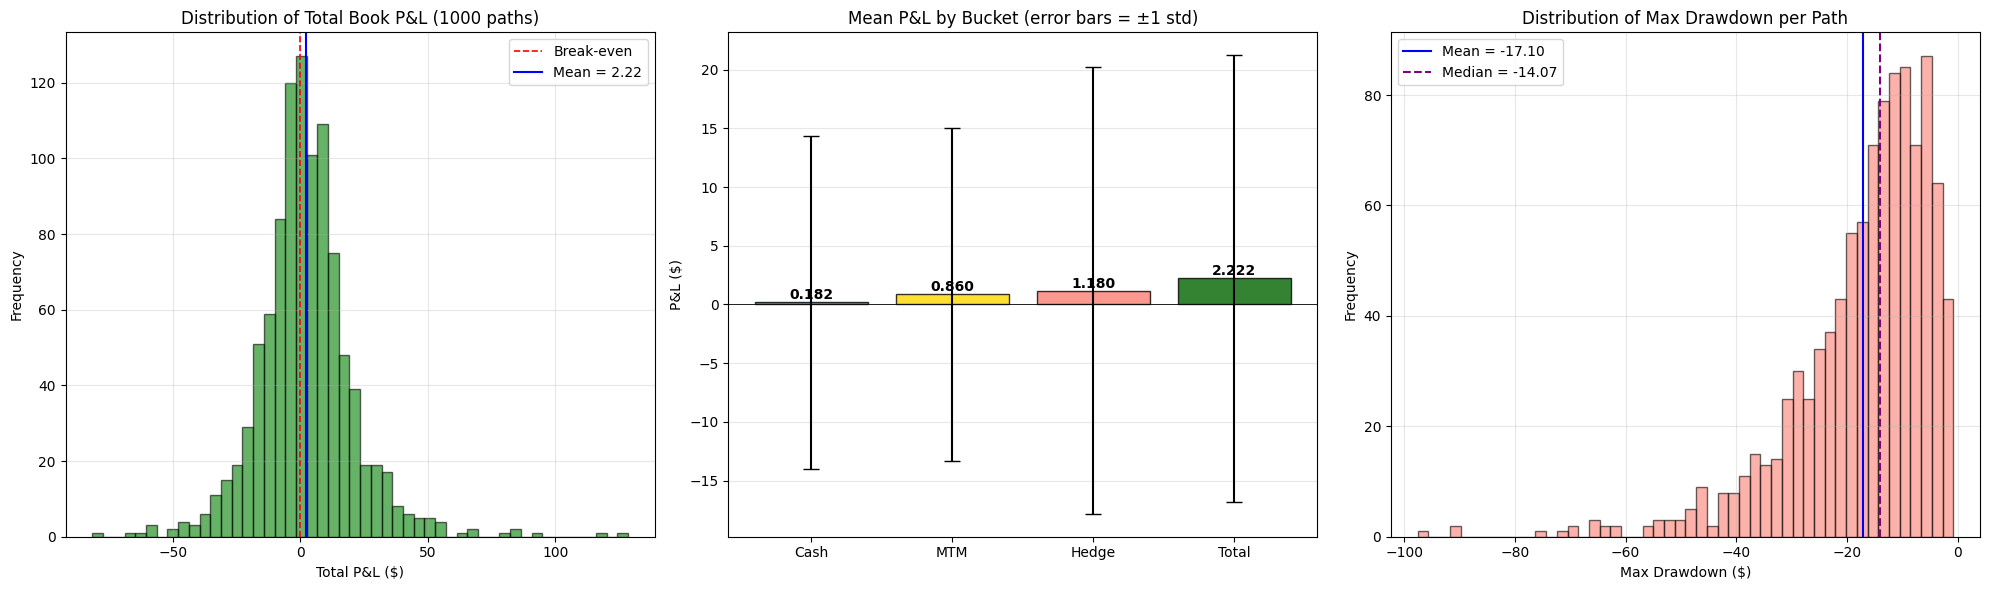

In [10]:
# --- MONTE CARLO: 1000 INDEPENDENT PATHS ---
N_RUNS = 1000

mc_cash  = np.zeros(N_RUNS)
mc_mtm   = np.zeros(N_RUNS)
mc_hedge = np.zeros(N_RUNS)
mc_total = np.zeros(N_RUNS)
mc_max_dd = np.zeros(N_RUNS)  # max drawdown per path

for run in range(N_RUNS):
    r = run_simulation(seed=run, track_daily=True)
    mc_cash[run]  = r['cash']
    mc_mtm[run]   = r['mtm']
    mc_hedge[run] = r['hedge']
    mc_total[run] = r['total']

    # max drawdown: largest peak-to-trough drop in daily P&L
    daily_pnl = np.array(r['total_pnl_track'])
    running_peak = np.maximum.accumulate(daily_pnl)
    drawdown = daily_pnl - running_peak  # always <= 0
    mc_max_dd[run] = drawdown.min()      # most negative = worst drawdown

    if (run + 1) % 100 == 0:
        print(f"Completed {run + 1}/{N_RUNS} runs")

print("\nMonte Carlo complete.")

# --- DISTRIBUTION SUMMARY TABLE ---
print("\n" + "=" * 75)
print(f"{'Bucket':<12} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10} {'% Positive':>12}")
print("=" * 75)

for label, arr in [('Cash',  mc_cash),
                   ('MTM',   mc_mtm),
                   ('Hedge', mc_hedge),
                   ('Total', mc_total)]:
    pct_pos = 100 * np.mean(arr > 0)
    print(f"{label:<12} {arr.mean():>10.4f} {arr.std():>10.4f} "
          f"{arr.min():>10.4f} {arr.max():>10.4f} {pct_pos:>11.1f}%")

print("=" * 75)

# --- RISK-ADJUSTED METRICS ---
sharpe = mc_total.mean() / mc_total.std() if mc_total.std() > 0 else float('nan')
print(f"\nSharpe ratio (per-path):     {sharpe:.4f}")
print(f"Mean max drawdown:           {mc_max_dd.mean():.4f}")
print(f"Worst max drawdown:          {mc_max_dd.min():.4f}")
print(f"Median max drawdown:         {np.median(mc_max_dd):.4f}")

# --- VISUALIZATIONS ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. HISTOGRAM OF TOTAL P&L
ax1 = axes[0]
ax1.hist(mc_total, bins=50, color='green', alpha=0.6, edgecolor='black')
ax1.axvline(0, color='red', linestyle='--', linewidth=1.2, label='Break-even')
ax1.axvline(mc_total.mean(), color='blue', linestyle='-', linewidth=1.5,
            label=f'Mean = {mc_total.mean():.2f}')
ax1.set_title(f'Distribution of Total Book P&L ({N_RUNS} paths)')
ax1.set_xlabel('Total P&L ($)')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. MEAN P&L BY BUCKET WITH ERROR BARS
ax2 = axes[1]
buckets = ['Cash', 'MTM', 'Hedge', 'Total']
means   = [mc_cash.mean(), mc_mtm.mean(), mc_hedge.mean(), mc_total.mean()]
stds    = [mc_cash.std(),  mc_mtm.std(),  mc_hedge.std(),  mc_total.std()]
colors  = ['steelblue', 'gold', 'salmon', 'darkgreen']

bars = ax2.bar(buckets, means, yerr=stds, capsize=6, color=colors,
               edgecolor='black', alpha=0.8)
ax2.axhline(0, color='black', linewidth=0.6)
ax2.set_title(f'Mean P&L by Bucket (error bars = ±1 std)')
ax2.set_ylabel('P&L ($)')
ax2.grid(True, alpha=0.3, axis='y')

for bar, m in zip(bars, means):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height,
             f'{m:.3f}',
             ha='center', va='bottom' if height >= 0 else 'top',
             fontsize=10, fontweight='bold')

# 3. DRAWDOWN DISTRIBUTION
ax3 = axes[2]
ax3.hist(mc_max_dd, bins=50, color='salmon', alpha=0.6, edgecolor='black')
ax3.axvline(mc_max_dd.mean(), color='blue', linestyle='-', linewidth=1.5,
            label=f'Mean = {mc_max_dd.mean():.2f}')
ax3.axvline(np.median(mc_max_dd), color='purple', linestyle='--', linewidth=1.5,
            label=f'Median = {np.median(mc_max_dd):.2f}')
ax3.set_title(f'Distribution of Max Drawdown per Path')
ax3.set_xlabel('Max Drawdown ($)')
ax3.set_ylabel('Frequency')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()